In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from mlxtend.plotting import plot_decision_regions

import plotly.express as px
import plotly.graph_objects as go

In [55]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
sns.set_theme()

In [5]:
data = pd.read_csv(r"..\data\eCommerce_Customer_support_data.csv")
data.shape

(85907, 20)

In [6]:
data.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [7]:
data.shape

(85907, 20)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [9]:
data.isnull().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

Features with missing values are Customer Remarks , Order_id, order_date_time, Customer_City, Product_category, Item_price, connected_handling_time        

In [10]:
data.nunique()

Unique id                  85907
channel_name                   3
category                      12
Sub-category                  57
Customer Remarks           18231
Order_id                   67675
order_date_time            13766
Issue_reported at          30923
issue_responded            30262
Survey_response_Date          31
Customer_City               1782
Product_category               9
Item_price                  2789
connected_handling_time      211
Agent_name                  1371
Supervisor                    40
Manager                        6
Tenure Bucket                  5
Agent Shift                    5
CSAT Score                     5
dtype: int64

In [11]:
sum(data.duplicated())

0

In [12]:
data.drop(["Unique id" , "Order_id"],axis = 1 , inplace = True)

In [13]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score'],
      dtype='object')

In [14]:
data.head()

,channel_name,category,Sub-category,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,Outcall,Product Queries,Life Insurance,NaN,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,Outcall,Product Queries,Product Specific Information,NaN,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,Inbound,Order Related,Installation/demo,NaN,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,Inbound,Returns,Reverse Pickup Enquiry,NaN,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,Inbound,Cancellation,Not Needed,NaN,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [15]:
# channel_name column analysis and preprocessing

data['channel_name'].isna().sum()

np.int64(0)

Basic Frequency Analysis

In [16]:
# Get value counts and proportions
channel_counts = data['channel_name'].value_counts()
channel_proportions = data['channel_name'].value_counts(normalize=True)

print("Channel Distribution:")
print(f"Counts:\n{channel_counts}")
print(f"Proportions:\n{channel_proportions}")


Channel Distribution:
Counts:
channel_name
Inbound    68142
Outcall    14742
Email       3023
Name: count, dtype: int64
Proportions:
channel_name
Inbound    0.793207
Outcall    0.171604
Email      0.035189
Name: proportion, dtype: float64


Channel-Csat relationship Analysis

In [17]:
# Cross-tabulation analysis
channel_csat_crosstab = pd.crosstab(data['channel_name'], data['CSAT Score'])
print("Channel vs CSAT Score Cross-tabulation:")
print(channel_csat_crosstab)

# Calculate CSAT statistics by channel
channel_csat_stats = data.groupby('channel_name')['CSAT Score'].agg(['mean', 'std', 'count'])
print("CSAT Statistics by Channel:")
print(channel_csat_stats)


Channel vs CSAT Score Cross-tabulation:
CSAT Score       1     2     3     4      5
channel_name                               
Email          636    64   102   388   1833
Inbound       8745  1011  2033  8934  47419
Outcall       1849   208   423  1897  10365
CSAT Statistics by Channel:
                  mean       std  count
channel_name                           
Email         3.899107  1.615222   3023
Inbound       4.251372  1.370008  68142
Outcall       4.269909  1.358055  14742


In [18]:
from scipy.stats import chi2_contingency, f_oneway

# Chi-square test for independence
chi2, p_value, dof, expected = chi2_contingency(channel_csat_crosstab)
print(f"Chi-square test p-value: {p_value}")

# ANOVA test for mean differences across channels
channel_groups = [data[data['channel_name'] == channel]['CSAT Score']
                  for channel in data['channel_name'].unique()]
f_stat, anova_p = f_oneway(*channel_groups)
print(f"ANOVA test p-value: {anova_p}")


Chi-square test p-value: 6.669001520780051e-39
ANOVA test p-value: 2.3194399795949356e-43


Based on the Chi square test of independence , there is significant relationship between the feature channel_name and the target csat_score.

Based on the One way anova test ,the mean of the csat score for atleast one of the channels in significantly different from other channels.

OHE encoding the channel_name column

In [19]:
# One-hot encoding
channel_encoded = pd.get_dummies(data['channel_name'], prefix='channel', drop_first=True)
data = pd.concat([data, channel_encoded], axis=1)


In [20]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'channel_Inbound', 'channel_Outcall'],
      dtype='object')

Data analysis and preprocessing of Category Column

In [21]:
data['category'].nunique()

12

In [22]:
# Value counts and proportions
category_counts = data['category'].value_counts()
category_props  = data['category'].value_counts(normalize=True)
print(category_counts)
print(category_props)


category
Returns               44097
Order Related         23215
Refund Related         4550
Product Queries        3692
Shopzilla Related      2792
Payments related       2327
Feedback               2294
Cancellation           2212
Offers & Cashback       480
Others                   99
App/website              84
Onboarding related       65
Name: count, dtype: int64
category
Returns               0.513311
Order Related         0.270234
Refund Related        0.052964
Product Queries       0.042977
Shopzilla Related     0.032500
Payments related      0.027087
Feedback              0.026703
Cancellation          0.025749
Offers & Cashback     0.005587
Others                0.001152
App/website           0.000978
Onboarding related    0.000757
Name: proportion, dtype: float64


In [23]:
# CSAT score distribution across categories


# Crosstab of counts
cat_crosstab = pd.crosstab(data['category'], data['CSAT Score'])
print(cat_crosstab)

# Mean, Std, Count of CSAT per category
cat_stats = data.groupby('category')['CSAT Score'].agg(['mean','std','count'])
print(cat_stats)


CSAT Score             1    2     3     4      5
category                                        
App/website           11    0     0     6     67
Cancellation         435   40    58   257   1422
Feedback             351   35    76   269   1563
Offers & Cashback     69    2    11    75    323
Onboarding related     9    1     2     5     48
Order Related       3730  422   826  3147  15090
Others                29    4     7    13     46
Payments related     238   35    69   307   1678
Product Queries      583   91   179   582   2257
Refund Related       618   65   121   609   3137
Returns             4824  549  1134  5613  31977
Shopzilla Related    333   39    75   336   2009
                        mean       std  count
category                                     
App/website         4.404762  1.354324     84
Cancellation        3.990506  1.585039   2212
Feedback            4.158675  1.458877   2294
Offers & Cashback   4.210417  1.402166    480
Onboarding related  4.261538  1.428252

In [24]:
from scipy.stats import chi2_contingency
chi2, p, _, _ = chi2_contingency(cat_crosstab)
print("Chi² p-value:", p)


Chi² p-value: 4.860086707285712e-152


There is a statistically significant association between category and csat score

In [25]:
from scipy.stats import f_oneway
groups = [grp['CSAT Score'].values for _, grp in data.groupby('category')]
f_stat, p_val = f_oneway(*groups)
print("ANOVA p-value:", p_val)


ANOVA p-value: 2.0102219401078283e-150


Based on the One way anova test ,the mean of the csat score for atleast one of the categories is significantly different from other categories.

In [26]:
data['category'].isnull().sum()

np.int64(0)

No missing values in categories

There is moderate cardinality (12 distinct values) in the feature.We will use target encoding for the feature.Target Encoding will replace each unique category with the mean csat score for that category

In [27]:
# Map each category to mean CSAT
target_map = data.groupby('category')['CSAT Score'].mean()
data['category_te'] = data['category'].map(target_map)


Also using Frequency encoding for this feature category

In [28]:
freq_map = data['category'].value_counts(normalize=True)
data['category_fe'] = data['category'].map(freq_map)

Data Analysis and preprocessing of sub category

In [29]:
data['Sub-category'].nunique()

57

In [30]:
data['Sub-category'].isna().sum()

np.int64(0)

In [31]:
sub_counts = data['Sub-category'].value_counts()
sub_props  = data['Sub-category'].value_counts(normalize=True)
print("TOP 10 SUB-CATEGORIES BASED ON THEIR COUNT")
print(sub_counts.head(10))
print(sub_props.head(10))


TOP 10 SUB-CATEGORIES BASED ON THEIR COUNT
Sub-category
Reverse Pickup Enquiry          22389
Return request                   8523
Delayed                          7388
Order status enquiry             6922
Installation/demo                4116
Fraudulent User                  4108
Product Specific Information     3589
Refund Enquiry                   2665
Wrong                            2597
Missing                          2556
Name: count, dtype: int64
Sub-category
Reverse Pickup Enquiry          0.260619
Return request                  0.099212
Delayed                         0.086000
Order status enquiry            0.080576
Installation/demo               0.047912
Fraudulent User                 0.047819
Product Specific Information    0.041778
Refund Enquiry                  0.031022
Wrong                           0.030230
Missing                         0.029753
Name: proportion, dtype: float64


RELATIONSHIP WITH CSAT

In [32]:
sub_crosstab = pd.crosstab(data['Sub-category'], data['CSAT Score'])
sub_crosstab

CSAT Score,1,2,3,4,5
Sub-category,,,,,
Account updation,34,6,5,13,92
Affiliate Offers,34,2,2,29,116
App/website Related,1,0,0,2,7
Billing Related,2,2,1,6,46
COD Refund Details,16,3,3,10,53
Call back request,11,1,6,9,19
Call disconnected,14,3,1,4,18
Card/EMI,5,1,0,0,13
Commission related,2,0,0,0,1


MEAN , STD AND COUNT FOR TOP 10 SUB CATEGORIES

In [33]:
sub_stats = data.groupby('Sub-category')['CSAT Score'].agg(['mean','std','count']) \
                .sort_values('count', ascending=False)
print(sub_stats.head(10))


                                  mean       std  count
Sub-category                                           
Reverse Pickup Enquiry        4.189468  1.422186  22389
Return request                4.613282  0.940458   8523
Delayed                       4.011505  1.534497   7388
Order status enquiry          4.210344  1.408775   6922
Installation/demo             3.883139  1.590585   4116
Fraudulent User               4.594937  1.004006   4108
Product Specific Information  4.044023  1.472059   3589
Refund Enquiry                4.296811  1.326308   2665
Wrong                         4.533308  1.104754   2597
Missing                       4.613850  0.989152   2556


CHI2 TEST OF INDEPENDENCE

In [34]:

top_ten_sub_crosstab = sub_crosstab.loc[sub_counts.head(10).index]
top_ten_sub_crosstab

CSAT Score,1,2,3,4,5
Sub-category,,,,,
Reverse Pickup Enquiry,3190,361,699,2906,15233
Return request,400,67,157,1181,6718
Delayed,1336,128,255,1065,4604
Order status enquiry,958,111,212,877,4764
Installation/demo,823,110,206,563,2414
Fraudulent User,239,23,72,495,3279
Product Specific Information,562,90,170,573,2194
Refund Enquiry,314,38,67,370,1876
Wrong,191,24,43,290,2049


In [35]:
chi2, p, _, _ = chi2_contingency(top_ten_sub_crosstab)
print("Chi² p-value:", p)

Chi² p-value: 0.0


This suggests very strong statistically significant association between sub-category and csat score

In [36]:
from scipy.stats import f_oneway

# Get the names of the top 10 sub-categories by count
top_10_subs = sub_counts.head(10).index

# Create a list of CSAT Score arrays for each top sub-category
sub_groups = [data[data['Sub-category'] == sub]['CSAT Score'] for sub in top_10_subs]

# Perform one-way ANOVA
f_stat, p_val = f_oneway(*sub_groups)
print("ANOVA p-value for top 10 sub-categories:", p_val)

ANOVA p-value for top 10 sub-categories: 0.0


Atleast one subcategory has a significantly different mean csat score

frequency encoding the sub category column

In [37]:
freq_map = data['Sub-category'].value_counts(normalize=True)
data['subcat_fe'] = data['Sub-category'].map(freq_map)


Target Encoding the sub category column

In [38]:
# K-fold target encoding to avoid leakage
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
data['subcat_te'] = np.nan

for train_idx, val_idx in kf.split(data):
    train, val = data.iloc[train_idx], data.iloc[val_idx]
    means = train.groupby('Sub-category')['CSAT Score'].mean()
    data.loc[val_idx, 'subcat_te'] = val['Sub-category'].map(means)

# For any unseen or all-null groups, fill with global mean
global_mean = data['CSAT Score'].mean()
data['subcat_te'].fillna(global_mean, inplace=True)


C:\Users\Ankur Bhatt\AppData\Local\Temp\ipykernel_27728\497214192.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['subcat_te'].fillna(global_mean, inplace=True)


In [39]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'channel_Inbound', 'channel_Outcall', 'category_te', 'category_fe',
       'subcat_fe', 'subcat_te'],
      dtype='object')

Data analysis and preprocessing of Customer Remarks column

In [40]:
data['Customer Remarks']

0                                             NaN
1                                             NaN
2                                             NaN
3                                             NaN
4                                             NaN
                           ...                   
85902                                         NaN
85903    Supported team customer executive   good
85904        need to improve with proper details.
85905                                         NaN
85906                                         NaN
Name: Customer Remarks, Length: 85907, dtype: object

In [41]:
# filling the null remarks with a placeholder 

data['Customer Remarks'].fillna("<Missing_Remark>" , inplace = True)

Character and Word length distribution

Character Length Distribution:
count    85907.000000
mean        25.162688
std         46.572114
min          1.000000
25%         16.000000
50%         16.000000
75%         16.000000
max       2673.000000
Name: remark_char_length, dtype: float64
Word Count Distribution:
count    85907.000000
mean         3.187889
std          8.444472
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        444.000000
Name: remark_word_count, dtype: float64


Text(0.5, 1.0, 'Word Count by CSAT Score')

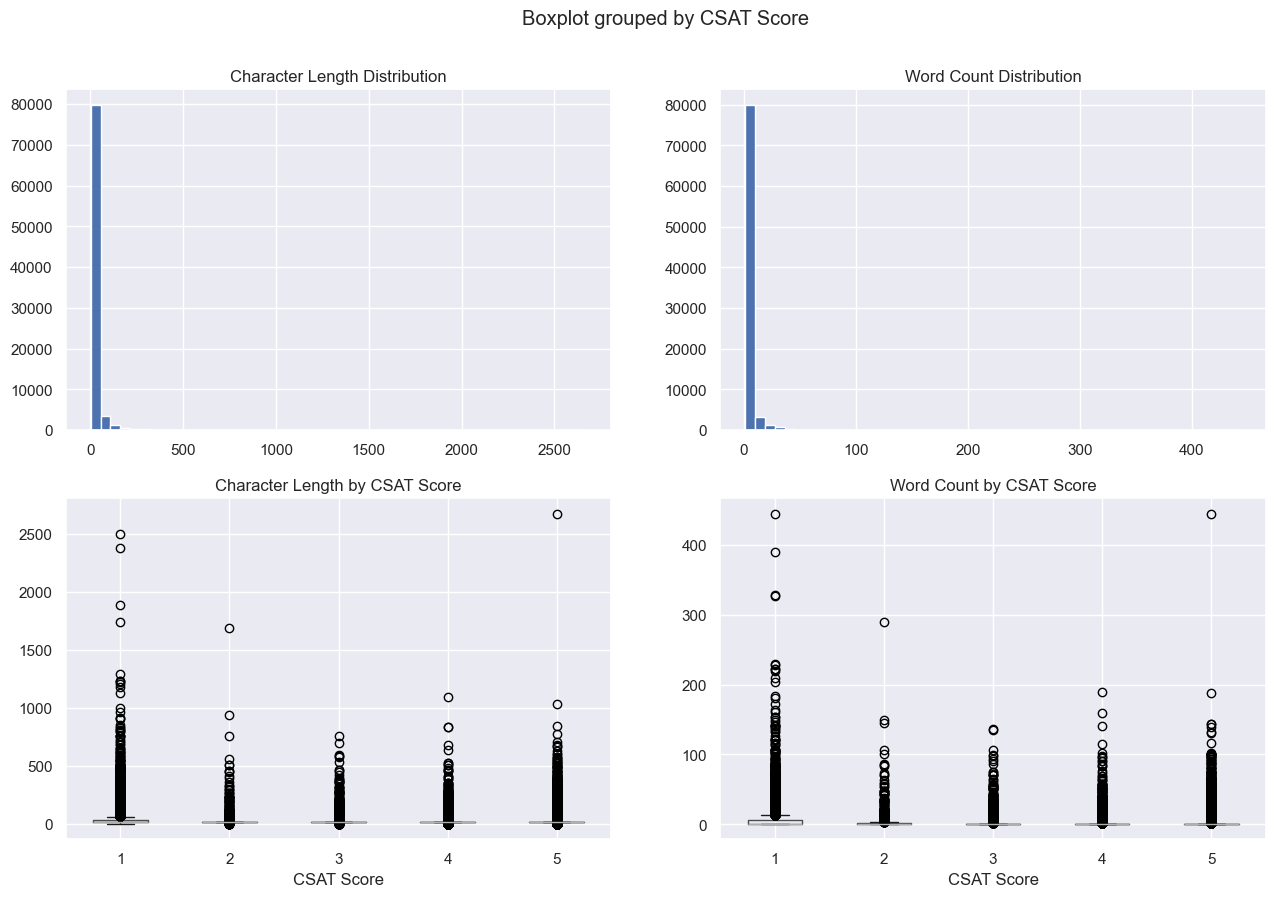

In [42]:
# Basic text statistics
data['remark_char_length'] = data['Customer Remarks'].str.len()
data['remark_word_count'] = data['Customer Remarks'].str.split().str.len()
data['remark_sentence_count'] = data['Customer Remarks'].str.split('.').str.len()

# Distribution analysis
print("Character Length Distribution:")
print(data['remark_char_length'].describe())

print("Word Count Distribution:")
print(data['remark_word_count'].describe())

# Visualizations
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Character length distribution
data['remark_char_length'].hist(bins=50, ax=axes[0,0])
axes[0,0].set_title('Character Length Distribution')

# Word count distribution  
data['remark_word_count'].hist(bins=50, ax=axes[0,1])
axes[0,1].set_title('Word Count Distribution')

# Box plots by CSAT Score
data.boxplot(column='remark_char_length', by='CSAT Score', ax=axes[1,0])
axes[1,0].set_title('Character Length by CSAT Score')

data.boxplot(column='remark_word_count', by='CSAT Score', ax=axes[1,1])
axes[1,1].set_title('Word Count by CSAT Score')


Missing Remark Analysis

In [43]:
# Analyze missing remarks pattern
missing_remarks_count = data[data['Customer Remarks'] == '<Missing_Remark>'].shape[0]
missing_percentage = (missing_remarks_count / len(data)) * 100

print(f"Missing Remarks: {missing_remarks_count} ({missing_percentage:.2f}%)")

# CSAT distribution for missing vs non-missing remarks
missing_csat = data[data['Customer Remarks'] == '<Missing_Remark>']['CSAT Score'].value_counts()
non_missing_csat = data[data['Customer Remarks'] != '<Missing_Remark>']['CSAT Score'].value_counts()

print("CSAT Distribution - Missing Remarks:")
print(missing_csat)
print("CSAT Distribution - Non-Missing Remarks:")
print(non_missing_csat)


Missing Remarks: 57165 (66.54%)
CSAT Distribution - Missing Remarks:
CSAT Score
5    39950
4     8616
1     5882
3     1828
2      889
Name: count, dtype: int64
CSAT Distribution - Non-Missing Remarks:
CSAT Score
5    19667
1     5348
4     2603
3      730
2      394
Name: count, dtype: int64


BASIC SENTIMENT AND CSAT CORRELATION ANALYSIS

In [44]:
from textblob import TextBlob
import pandas as pd

# Basic sentiment analysis (excluding missing remarks)
non_missing_data = data[data['Customer Remarks'] != '<Missing_Remark>'].copy()

def get_sentiment_scores(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

# Apply sentiment analysis
sentiment_scores = non_missing_data['Customer Remarks'].apply(get_sentiment_scores)
non_missing_data['sentiment_polarity'] = [score[0] for score in sentiment_scores]
non_missing_data['sentiment_subjectivity'] = [score[1] for score in sentiment_scores]

# Correlation with CSAT
sentiment_csat_corr = non_missing_data[['sentiment_polarity', 'sentiment_subjectivity', 'CSAT Score']].corr()
print("Sentiment-CSAT Correlation:")
print(sentiment_csat_corr)

# Sentiment distribution by CSAT Score
sentiment_by_csat = non_missing_data.groupby('CSAT Score')[['sentiment_polarity', 'sentiment_subjectivity']].mean()
print("Average Sentiment by CSAT Score:")
print(sentiment_by_csat)


Sentiment-CSAT Correlation:
                        sentiment_polarity  sentiment_subjectivity  CSAT Score
sentiment_polarity                1.000000                0.422366    0.522431
sentiment_subjectivity            0.422366                1.000000    0.120746
CSAT Score                        0.522431                0.120746    1.000000
Average Sentiment by CSAT Score:
            sentiment_polarity  sentiment_subjectivity
CSAT Score                                            
1                    -0.169262                0.384283
2                     0.023047                0.349440
3                     0.118096                0.357286
4                     0.297927                0.412265
5                     0.425706                0.487173


There is significant correlation between sentiment polarity and csat score (= 0.522)

With the increase in csat score , we can see significant change in sentiment polarity scores.Sentiment subjectivity score also tends to increase slighly with increase in csat score.

However we have to keep in mind that textblob model is not deep learning sentiment analysis model . It is rather a lexicon based model where each word has predefined polarity and subjectivity scores . Its scores may not do well on contextual understanding of the text like inefficient understanding of sarcasm or ambiguous text.

Unigram , Bigram and N-gram analysis for pattern discovery : Identifying common phrases and patterns

In [45]:
from sklearn.feature_extraction.text import CountVectorizer
import re

# Clean text for n-gram analysis (excluding missing remarks)
def basic_clean_for_ngram(text):
    if text == '<Missing_Remark>':
        return text
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

non_missing_data['cleaned_remarks'] = non_missing_data['Customer Remarks'].apply(basic_clean_for_ngram)

# Unigram analysis
unigram_vectorizer = CountVectorizer(ngram_range=(1,1), stop_words='english', max_features=50)
unigram_matrix = unigram_vectorizer.fit_transform(non_missing_data['cleaned_remarks'])
unigram_freq = dict(zip(unigram_vectorizer.get_feature_names_out(), 
                       unigram_matrix.sum(axis=0).A1))
print("Top 20 Unigrams:")
for word, freq in sorted(unigram_freq.items(), key=lambda x: x[1], reverse=True)[:20]:
    print(f"{word}: {freq}")

# Bigram analysis  
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=30)
bigram_matrix = bigram_vectorizer.fit_transform(non_missing_data['cleaned_remarks'])
bigram_freq = dict(zip(bigram_vectorizer.get_feature_names_out(), 
                      bigram_matrix.sum(axis=0).A1))
print("\nTop 15 Bigrams:")
for bigram, freq in sorted(bigram_freq.items(), key=lambda x: x[1], reverse=True)[:15]:
    print(f"{bigram}: {freq}")

# N-gram analysis by CSAT score
for csat_score in sorted(non_missing_data['CSAT Score'].unique()):
    csat_remarks = non_missing_data[non_missing_data['CSAT Score'] == csat_score]['cleaned_remarks']
    if len(csat_remarks) > 0:
        vectorizer = CountVectorizer(ngram_range=(1,2), stop_words='english', max_features=10)
        matrix = vectorizer.fit_transform(csat_remarks)
        freq = dict(zip(vectorizer.get_feature_names_out(), matrix.sum(axis=0).A1))
        print(f"\nTop phrases for CSAT Score {csat_score}:")
        for phrase, f in sorted(freq.items(), key=lambda x: x[1], reverse=True)[:5]:
            print(f"  {phrase}: {f}")


Top 20 Unigrams:
good: 8191
customer: 3723
shopzilla: 2801
service: 2458
product: 1937
nice: 1901
support: 1619
thank: 1492
delivery: 1452
issue: 1448
thanks: 1389
problem: 1369
executive: 1299
time: 1275
care: 1219
order: 1021
return: 904
happy: 862
bad: 812
solve: 698

Top 15 Bigrams:
customer care: 958
customer support: 748
customer service: 625
good service: 390
customer executive: 237
issue resolved: 222
support executive: 205
good customer: 204
solve problem: 203
care executive: 200
resolve issue: 196
good job: 178
thanks shopzilla: 174
shopzilla customer: 173
thank shopzilla: 173

Top phrases for CSAT Score 1:
  shopzilla: 1101
  customer: 1040
  service: 915
  product: 790
  bad: 621

Top phrases for CSAT Score 2:
  shopzilla: 67
  customer: 64
  product: 60
  good: 45
  delivery: 43

Top phrases for CSAT Score 3:
  good: 114
  customer: 106
  product: 102
  shopzilla: 98
  delivery: 89

Top phrases for CSAT Score 4:
  good: 769
  customer: 286
  product: 223
  shopzilla: 193
 

Top 10 Trigrama  and tri gram analysis by csat score

In [46]:
# non_missing_data['cleaned_remarks']

# Trigram analysis
trigram_vectorizer = CountVectorizer(ngram_range=(3,3), stop_words='english', max_features=20)
trigram_matrix = trigram_vectorizer.fit_transform(non_missing_data['cleaned_remarks'])
trigram_freq = dict(zip(trigram_vectorizer.get_feature_names_out(), 
                       trigram_matrix.sum(axis=0).A1))
print("Top 10 Trigrams:")
for trigram, freq in sorted(trigram_freq.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{trigram}: {freq}")
# tri-gram analysis by CSAT score
for csat_score in sorted(non_missing_data['CSAT Score'].unique()):
    csat_remarks = non_missing_data[non_missing_data['CSAT Score'] == csat_score]['cleaned_remarks']
    if len(csat_remarks) > 0:
        vectorizer = CountVectorizer(ngram_range=(3,3), stop_words='english', max_features=10)
        matrix = vectorizer.fit_transform(csat_remarks)
        freq = dict(zip(vectorizer.get_feature_names_out(), matrix.sum(axis=0).A1))
        print(f"\nTop phrases for CSAT Score {csat_score}:")
        for phrase, f in sorted(freq.items(), key=lambda x: x[1], reverse=True)[:5]:
            print(f"  {phrase}: {f}")


Top 10 Trigrams:
customer care executive: 178
customer support executive: 152
customer care service: 94
shopzilla customer care: 76
good customer support: 67
good customer service: 64
customer service good: 62
open box delivery: 54
customer care support: 50
customer service executive: 47

Top phrases for CSAT Score 1:
  customer care executive: 43
  worst customer service: 24
  customer support executive: 23
  bad experience shopzilla: 20
  worst service shopzilla: 18

Top phrases for CSAT Score 2:
  want return product: 4
  customer care executive: 3
  shown opd facility: 3
  open box delivery: 2
  pay later account: 2

Top phrases for CSAT Score 3:
  customer care executive: 4
  open box delivery: 4
  money deducted order: 2
  need lodge complaint: 2
  non returnable products: 2

Top phrases for CSAT Score 4:
  customer care executive: 10
  customer support executive: 10
  problem soon possible: 7
  customer support good: 6
  customer care number: 5

Top phrases for CSAT Score 5:
  c

Identifying Key themes in customer remarks using Topic Modelling 

In [47]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer

# Advanced text preprocessing for topic modeling
def preprocess_for_topics(text):
    if text == '<Missing_Remark>':
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove very short texts
    if len(text.split()) < 3:
        return ""
    return text

topic_data = non_missing_data['Customer Remarks'].apply(preprocess_for_topics)
topic_data = topic_data[topic_data != ""]  # Remove empty strings

# TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=200, stop_words='english',
                                  ngram_range=(1,2), min_df=5, max_df=0.7)
tfidf_matrix = tfidf_vectorizer.fit_transform(topic_data)

# LDA topic modeling
n_topics = 8
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=100)
lda.fit(tfidf_matrix)

# Display top words per topic
feature_names = tfidf_vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-10:]]
    print(f"Topic {topic_idx + 1}: {', '.join(reversed(top_words))}")


Topic 1: support, nice, happy, customer support, customer, talk, good, solved, best, response
Topic 2: care, customer care, customer, thank, help, good, communication, make, conversation, care executive
Topic 3: service, shopzilla, customer service, person, worst, poor, customer, good, work, great
Topic 4: executive, sir, agent, provide, resolution, satisfied, customer executive, good, good service, possible
Topic 5: issue, resolved, resolve, problem, behaviour, helpful, query, issue resolved, issues, excellent
Topic 6: good, bad, experience, hai, thank, shopzilla, se, talking, mam, bahut
Topic 7: thanks, solve, problem, refund, solve problem, information, helping, issue, problems, bad service
Topic 8: product, delivery, order, return, time, policy, products, shopzilla, delivered, improve


In [48]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'channel_Inbound', 'channel_Outcall', 'category_te', 'category_fe',
       'subcat_fe', 'subcat_te', 'remark_char_length', 'remark_word_count',
       'remark_sentence_count'],
      dtype='object')

Preprocessing of Customer Remarks

In [49]:
import re
import nltk
from nltk.corpus import stopwords  
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

class CustomerRemarksPreprocessor:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
        
    def clean_text(self, text):
        """Comprehensive text cleaning"""
        # Handle missing remarks token
        if text == '<Missing_Remark>':
            return '<MISSING>'
            
        # Convert to lowercase
        text = text.lower()
        
        # Remove HTML tags if any
        text = re.sub(r'<[^>]+>', '', text)
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)
        
        # Remove extra whitespace and newlines
        text = re.sub(r'\s+', ' ', text)
        
        # Remove punctuation except important ones for sentiment
        # Keep some punctuation that might be important for sentiment
        text = re.sub(r'[^\w\s!?.]', ' ', text)
        
        return text.strip()
    
    def tokenize_and_lemmatize(self, text):
        """Tokenization and lemmatization"""
        if text == '<MISSING>':
            return ['<MISSING>']
            
        # Tokenize
        tokens = word_tokenize(text)
        
        # Remove stopwords and lemmatize
        tokens = [self.lemmatizer.lemmatize(token) for token in tokens 
                 if token not in self.stop_words and len(token) > 2]
        
        # Filter out tokens that are just punctuation
        tokens = [token for token in tokens if not all(c in string.punctuation for c in token)]
        
        return tokens
    
    def preprocess(self, text):
        """Complete preprocessing pipeline"""
        cleaned_text = self.clean_text(text)
        tokens = self.tokenize_and_lemmatize(cleaned_text)
        return ' '.join(tokens)

# Apply preprocessing
preprocessor = CustomerRemarksPreprocessor()
data['cleaned_remarks'] = data['Customer Remarks'].apply(preprocessor.preprocess)

print("Preprocessing completed. Sample results:")
print(data[['Customer Remarks', 'cleaned_remarks']].head())


[nltk_data] Downloading package punkt to C:\Users\Ankur
[nltk_data]     Bhatt\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Ankur
[nltk_data]     Bhatt\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Ankur
[nltk_data]     Bhatt\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Ankur Bhatt\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Preprocessing completed. Sample results:
   Customer Remarks cleaned_remarks
0  <Missing_Remark>       <MISSING>
1  <Missing_Remark>       <MISSING>
2  <Missing_Remark>       <MISSING>
3  <Missing_Remark>       <MISSING>
4  <Missing_Remark>       <MISSING>


In [50]:
data[['Customer Remarks', 'cleaned_remarks']].sample(10)

,Customer Remarks,cleaned_remarks
33438,<Missing_Remark>,<MISSING>
20243,<Missing_Remark>,<MISSING>
55465,<Missing_Remark>,<MISSING>
65372,<Missing_Remark>,<MISSING>
3459,Resolve my refund issue asap,resolve refund issue asap
71437,Exchange option should be in every products.,exchange option every product
60573,5,
37839,good,good
35174,<Missing_Remark>,<MISSING>
48365,<Missing_Remark>,<MISSING>


In [51]:
data.head()

,channel_name,category,Sub-category,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,...,channel_Inbound,channel_Outcall,category_te,category_fe,subcat_fe,subcat_te,remark_char_length,remark_word_count,remark_sentence_count,cleaned_remarks
0,Outcall,Product Queries,Life Insurance,<Missing_Remark>,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,...,False,True,4.039816,0.042977,0.000268,4.230769,16,1,1,<MISSING>
1,Outcall,Product Queries,Product Specific Information,<Missing_Remark>,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,...,False,True,4.039816,0.042977,0.041778,4.013627,16,1,1,<MISSING>
2,Inbound,Order Related,Installation/demo,<Missing_Remark>,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,...,True,False,4.096059,0.270234,0.047912,3.865802,16,1,1,<MISSING>
3,Inbound,Returns,Reverse Pickup Enquiry,<Missing_Remark>,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,...,True,False,4.346350,0.513311,0.260619,4.191937,16,1,1,<MISSING>
4,Inbound,Cancellation,Not Needed,<Missing_Remark>,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,...,True,False,3.990506,0.025749,0.022350,3.921189,16,1,1,<MISSING>


Sequence preparation for the LSTM text branch

In [54]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

class SequencePreprocessor:
    def __init__(self, max_words=10000, max_len=100):
        self.max_words = max_words
        self.max_len = max_len
        self.tokenizer = None
        
    def fit_tokenizer(self, texts):
        """Fit tokenizer on text data"""
        self.tokenizer = Tokenizer(num_words=self.max_words, oov_token='<OOV>')
        self.tokenizer.fit_on_texts(texts)
        print(f"Vocabulary size: {len(self.tokenizer.word_index)}")
        
    def texts_to_sequences(self, texts):
        """Convert texts to sequences"""
        sequences = self.tokenizer.texts_to_sequences(texts)
        padded_sequences = pad_sequences(sequences, maxlen=self.max_len, padding='post')
        return padded_sequences
    
    def get_vocab_size(self):
        """Get actual vocabulary size for embedding layer"""
        return min(len(self.tokenizer.word_index) + 1, self.max_words)

# Analyze sequence lengths to determine max_len
sequence_lengths = data['cleaned_remarks'].apply(lambda x: len(x.split()))
print("Sequence length statistics:")
print(sequence_lengths.describe())
print(f"95th percentile: {sequence_lengths.quantile(0.95)}")
print(f"99th percentile: {sequence_lengths.quantile(0.99)}")

# Choose max_len based on analysis (e.g., 95th percentile)
MAX_LEN = int(sequence_lengths.quantile(0.95))
print(f"Selected MAX_LEN: {MAX_LEN}")

# Initialize and fit sequence preprocessor
seq_processor = SequencePreprocessor(max_words=10000, max_len=MAX_LEN)
seq_processor.fit_tokenizer(data['cleaned_remarks'])

# Convert to sequences
X_text_sequences = seq_processor.texts_to_sequences(data['cleaned_remarks'])
print(f"Text sequences shape: {X_text_sequences.shape}")

# Save preprocessor for later use
import pickle
with open('text_preprocessor.pkl', 'wb') as f:
    pickle.dump(seq_processor, f)


d:\Deep Learning Projects\Deep CSAT - Ecommerce Customer Satisfaction Score Prediction\csat_venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
d:\Deep Learning Projects\Deep CSAT - Ecommerce Customer Satisfaction Score Prediction\csat_venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
d:\Deep Learning Projects\Deep CSAT - Ecommerce Customer Satisfaction Score Prediction\csat_venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning:

Sequence length statistics:
count    85907.000000
mean         2.129012
std          4.366201
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        263.000000
Name: cleaned_remarks, dtype: float64
95th percentile: 8.0
99th percentile: 19.0
Selected MAX_LEN: 8
Vocabulary size: 9241
Text sequences shape: (85907, 8)


In [59]:
X_text_sequences.shape

(85907, 8)

Creating Context Retaining embeddings using LSTM for CustomerRemarks

In [60]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import Model

# Text branch architecture
def create_text_branch(vocab_size, embedding_dim=100, lstm_units=64, max_len=MAX_LEN):
    """
    Customer_Remarks -> Embedding -> LSTM -> Dense(64)
    """
    # Text input
    text_input = Input(shape=(max_len,), name='text_input')
    
    # Embedding layer
    # You can use pre-trained embeddings here if needed
    text_embed = Embedding(input_dim=vocab_size, 
                          output_dim=embedding_dim,
                          input_length=max_len,
                          name='text_embedding')(text_input)
    
    # LSTM layer
    text_lstm = LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2,
                    name='text_lstm')(text_embed)
    
    # Dense layer
    text_dense = Dense(64, activation='relu', name='text_dense')(text_lstm)
    text_dropout = Dropout(0.3)(text_dense)
    
    return text_input, text_dropout

# Create the text branch
vocab_size = seq_processor.get_vocab_size()
text_input, text_features = create_text_branch(vocab_size)

print(f"Text branch created with vocab_size: {vocab_size}")
print(f"Text features output shape: (batch_size, 64)")


Text branch created with vocab_size: 9242
Text features output shape: (batch_size, 64)


In [64]:
text_features.shape

(None, 64)

In [65]:
text_input.shape

(None, 8)

In [ ]:
# Wrap the text branch into a model
text_encoder = Model(inputs=text_input, outputs=text_features)

# Generate embeddings for customer remarks
X_embeddings = text_encoder.predict(X_text_sequences, batch_size=32)
print(X_embeddings.shape)  # (85907, 64)


2685/2685 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
(85907, 64)


In [67]:
data.head()

,channel_name,category,Sub-category,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,...,channel_Inbound,channel_Outcall,category_te,category_fe,subcat_fe,subcat_te,remark_char_length,remark_word_count,remark_sentence_count,cleaned_remarks
0,Outcall,Product Queries,Life Insurance,<Missing_Remark>,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,...,False,True,4.039816,0.042977,0.000268,4.230769,16,1,1,<MISSING>
1,Outcall,Product Queries,Product Specific Information,<Missing_Remark>,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,...,False,True,4.039816,0.042977,0.041778,4.013627,16,1,1,<MISSING>
2,Inbound,Order Related,Installation/demo,<Missing_Remark>,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,...,True,False,4.096059,0.270234,0.047912,3.865802,16,1,1,<MISSING>
3,Inbound,Returns,Reverse Pickup Enquiry,<Missing_Remark>,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,...,True,False,4.346350,0.513311,0.260619,4.191937,16,1,1,<MISSING>
4,Inbound,Cancellation,Not Needed,<Missing_Remark>,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,...,True,False,3.990506,0.025749,0.022350,3.921189,16,1,1,<MISSING>


Dropping the Encoded Columns

In [68]:
data.drop(['channel_name', 'category', 'Sub-category', 'Customer Remarks'], axis=1, inplace=True)

In [69]:
data.head()

,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,...,channel_Inbound,channel_Outcall,category_te,category_fe,subcat_fe,subcat_te,remark_char_length,remark_word_count,remark_sentence_count,cleaned_remarks
0,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,...,False,True,4.039816,0.042977,0.000268,4.230769,16,1,1,<MISSING>
1,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,...,False,True,4.039816,0.042977,0.041778,4.013627,16,1,1,<MISSING>
2,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,...,True,False,4.096059,0.270234,0.047912,3.865802,16,1,1,<MISSING>
3,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,...,True,False,4.346350,0.513311,0.260619,4.191937,16,1,1,<MISSING>
4,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,...,True,False,3.990506,0.025749,0.022350,3.921189,16,1,1,<MISSING>


In [70]:
non_missing_data.shape

(28742, 30)

In [71]:
non_missing_data.head()

,channel_name,category,Sub-category,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,...,category_te,category_fe,subcat_fe,subcat_te,remark_char_length,remark_word_count,remark_sentence_count,sentiment_polarity,sentiment_subjectivity,cleaned_remarks
7,Inbound,Returns,Exchange / Replacement,Very good,NaN,01/08/2023 16:17,01/08/2023 16:23,01-Aug-23,NaN,NaN,...,4.346350,0.513311,0.010430,4.057746,9,2,1,0.91,0.780000,very good
8,Inbound,Returns,Missing,Shopzilla app and it's all coustomer care serv...,NaN,01/08/2023 21:03,01/08/2023 21:07,01-Aug-23,NaN,NaN,...,4.346350,0.513311,0.029753,4.617124,89,15,1,0.91,0.780000,shopzilla app and its all coustomer care servi...
11,Inbound,Order Related,Delayed,Very bad,19/07/2023 23:50,02/08/2023 10:44,02/08/2023 11:14,02-Aug-23,NAGPUR,LifeStyle,...,4.096059,0.270234,0.086000,4.018881,8,2,1,-0.91,0.866667,very bad
17,Inbound,Order Related,Installation/demo,Something,NaN,01/08/2023 10:00,01/08/2023 10:04,01-Aug-23,NaN,NaN,...,4.096059,0.270234,0.047912,3.906536,10,1,1,0.00,0.000000,something
19,Inbound,Order Related,Installation/demo,All good,18/07/2023 12:20,02/08/2023 20:03,02/08/2023 20:05,02-Aug-23,NAGPUR,Electronics,...,4.096059,0.270234,0.047912,3.906536,8,2,1,0.70,0.600000,all good


In [76]:
non_missing_data.index

Index([    7,     8,    11,    17,    19,    21,    23,    25,    27,    29,
       ...
       85874, 85876, 85879, 85881, 85882, 85887, 85888, 85896, 85903, 85904],
      dtype='int64', length=28742)

In [78]:
non_missing_data.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'channel_Inbound', 'channel_Outcall', 'category_te', 'category_fe',
       'subcat_fe', 'subcat_te', 'remark_char_length', 'remark_word_count',
       'remark_sentence_count', 'sentiment_polarity', 'sentiment_subjectivity',
       'cleaned_remarks'],
      dtype='object')

In [77]:
data.columns

Index(['order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'channel_Inbound', 'channel_Outcall', 'category_te', 'category_fe',
       'subcat_fe', 'subcat_te', 'remark_char_length', 'remark_word_count',
       'remark_sentence_count', 'cleaned_remarks'],
      dtype='object')

I want two new features in data df sentimentpolarity and sentimentsubjectivity where i want to fill the values from non missing data df , where there are missing remark put 0 for polarity and subjectivity , also create a feature has_missing_remark a binary feature . this will give the extra information. 